# Depth maps in supervision: a playground

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow/supervision/blob/playground/depth-maps/examples/depth_playground.ipynb)

A depth map stores, for every pixel of an image, how far that point is from the camera. This notebook tries four draft pull requests together, one section each:

1. [#2691](https://github.com/roboflow/supervision/pull/2691): `sv.DepthMap` holds a depth map and `sv.DepthAnnotator` colours it over an image.
2. [#2692](https://github.com/roboflow/supervision/pull/2692): `sv.DepthClipRange` keeps one colour range for a whole video, so a colour means the same depth on every frame.
3. [#2693](https://github.com/roboflow/supervision/pull/2693): `sv.DepthCamera` turns stereo disparity into metres, and `measure_detections` labels objects with their distance.
4. [#2694](https://github.com/roboflow/supervision/pull/2694): loaders for Roboflow Inference, Ultralytics, Hugging Face Transformers and the 16-bit PNG and PFM files depth datasets ship.

**How to run:** Runtime > Run all. A CPU runtime is fine (about two minutes); a GPU runtime is faster. The outputs below are from a full run, so you can also just read.

In [1]:
import os

# Set DEPTH_PLAYGROUND_LOCAL=1 to skip the install when supervision is already set up.
SUPERVISION = "git+https://github.com/roboflow/supervision@playground/depth-maps"
if os.environ.get("DEPTH_PLAYGROUND_LOCAL") != "1":
    %pip install -q {SUPERVISION} ultralytics transformers opencv-python-headless

### Download the data

A stereo pair from the [Middlebury 2014](https://vision.middlebury.edu/stereo/data/scenes2014/) dataset (two photos of a chair taken side by side, with measured ground truth) and a street video from Roboflow.

In [2]:
from pathlib import Path

import cv2
import numpy as np
import requests
from IPython.display import Markdown, Video
from PIL import Image

import supervision as sv

DATA = Path("data")
DATA.mkdir(exist_ok=True)
MIDDLEBURY_URL = (
    "https://vision.middlebury.edu/stereo/data/scenes2014/datasets/Adirondack-perfect/"
)
VIDEO_URL = "https://media.roboflow.com/supervision/video-examples/people-walking.mp4"


def download(url: str, path: Path) -> Path:
    # Skip files already downloaded by an earlier run.
    if not path.exists():
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        path.write_bytes(response.content)
    return path


for name in ("im0.png", "im1.png", "disp0.pfm", "calib.txt"):
    download(MIDDLEBURY_URL + name, DATA / name)
VIDEO_PATH = download(VIDEO_URL, DATA / "people-walking.mp4")

# The photos are 2880 x 1988; a quarter of that keeps every cell quick.
SIZE = (720, 497)


def load_photo(path: Path) -> np.ndarray:
    # A BGR array at SIZE, the layout supervision annotators draw on.
    photo = Image.open(path).convert("RGB").resize(SIZE, Image.Resampling.BOX)
    return sv.pillow_to_cv2(photo)


left = load_photo(DATA / "im0.png")
right = load_photo(DATA / "im1.png")
print("supervision", sv.__version__)

supervision 0.31.0.dev0


## 1. Colour a depth map (PR #2691)

A stereo camera takes two photos from slightly different positions. A point near the camera shifts more between the two photos than a far one; that shift, in pixels, is called **disparity**, so larger disparity means nearer. Here is the pair: compare where the chair sits against the background in each.

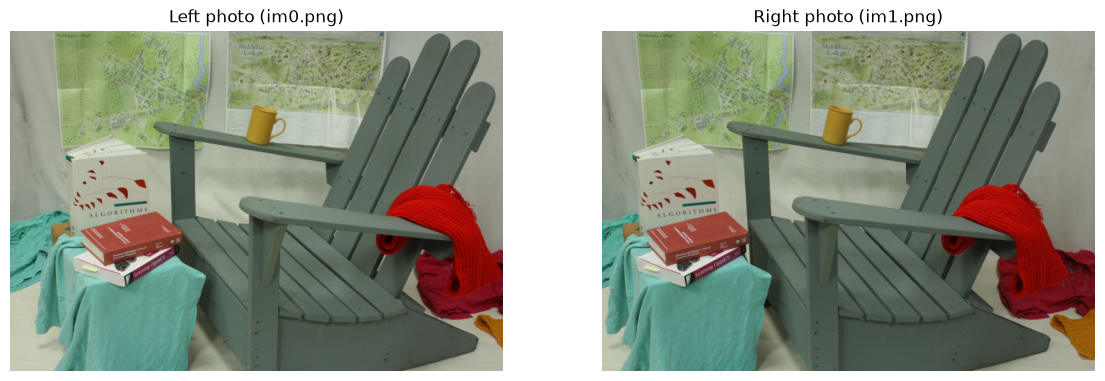

In [3]:
sv.plot_images_grid(
    [left, right],
    grid_size=(1, 2),
    titles=["Left photo (im0.png)", "Right photo (im1.png)"],
    size=(14, 5),
)

OpenCV's StereoSGBM matcher estimates the disparity of each pixel from the pair. It cannot match everything (the left edge only one camera sees, plain surfaces, spots hidden from one camera), so its map has holes. `sv.DepthMap` holds the map and `sv.DepthAnnotator` paints it: warm colours are near, cool ones far, and pixels with no depth stay unpainted, so the photo shows through on the left and black shows through on the right.

DepthMap(kind='disparity_px', resolution_wh=(720, 497), camera=None)
81% of pixels have a disparity


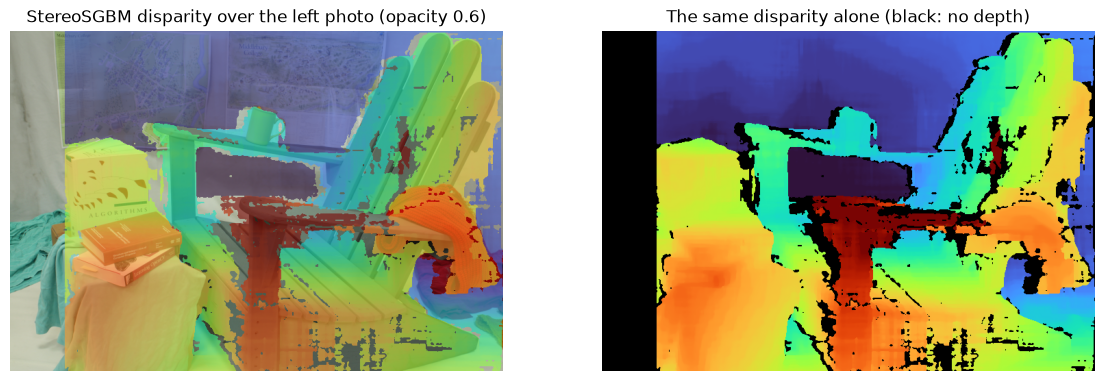

In [4]:
matcher = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=80,
    blockSize=5,
    P1=8 * 3 * 25,
    P2=32 * 3 * 25,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=2,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY,
)
gray_left = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)
# OpenCV returns 16 x disparity as int16, and a negative value where it found no match.
disparity = matcher.compute(gray_left, gray_right).astype(np.float32) / 16
stereo_map = sv.DepthMap(disparity, kind="disparity_px")
print(stereo_map)
print(f"{stereo_map.valid_mask.mean():.0%} of pixels have a disparity")

overlay = sv.DepthAnnotator(opacity=0.6).annotate(left.copy(), stereo_map)
depth_only = sv.DepthAnnotator().annotate(np.zeros_like(left), stereo_map)
sv.plot_images_grid(
    [overlay, depth_only],
    grid_size=(1, 2),
    titles=[
        "StereoSGBM disparity over the left photo (opacity 0.6)",
        "The same disparity alone (black: no depth)",
    ],
    size=(14, 5),
)

The next grid shows the dataset's true disparity, measured with structured light, in each of the six colour tables. It is loaded with `sv.DepthMap.from_pfm`, one of the loaders from PR #2694 (section 4). `turbo`, the default, separates the most depth steps; `viridis` and `cividis` keep their order when printed in grayscale and for colour-blind readers.

DepthMap(kind='disparity_px', resolution_wh=(2880, 1988), camera=None) -> DepthMap(kind='disparity_px', resolution_wh=(720, 497), camera=None)


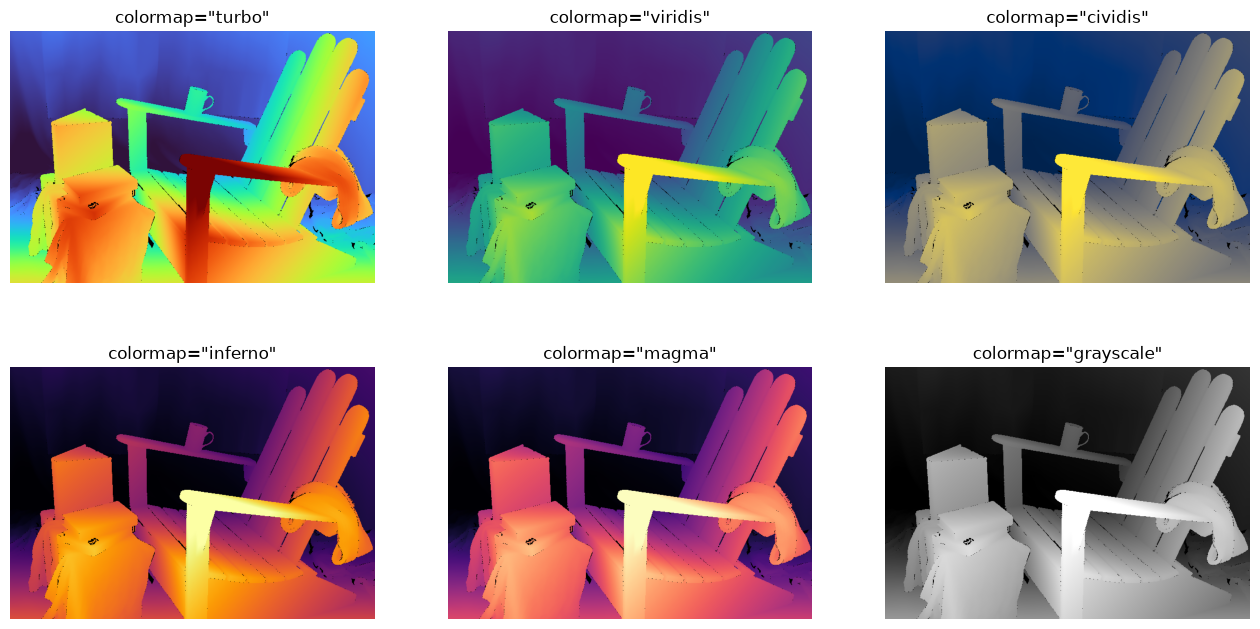

In [5]:
truth_full = sv.DepthMap.from_pfm(DATA / "disp0.pfm")
# Shrinking the map to a quarter of the width also divides each disparity by 4.
truth = truth_full.resize(SIZE)
print(truth_full, "->", truth)

colormaps = list(sv.DepthColormap)
canvases = [
    sv.DepthAnnotator(colormap=colormap).annotate(np.zeros_like(left), truth)
    for colormap in colormaps
]
sv.plot_images_grid(
    canvases,
    grid_size=(2, 3),
    titles=[f'colormap="{colormap.value}"' for colormap in colormaps],
    size=(16, 8),
)

By default the colours span the map's own 2nd to 98th percentile (`display_range="auto"`), so they always use the full table but a colour means a different disparity in every image. A fixed `(low, high)` range, in pixels of disparity here, pins each colour to one value, so images coloured with the same range compare directly; values outside the range take the end colours. With `(30, 50)` the colours go to the front of the chair: the nearest armrest clamps to dark red, and everything farther than 30 pixels, the room and the back of the chair, clamps to the darkest blue.

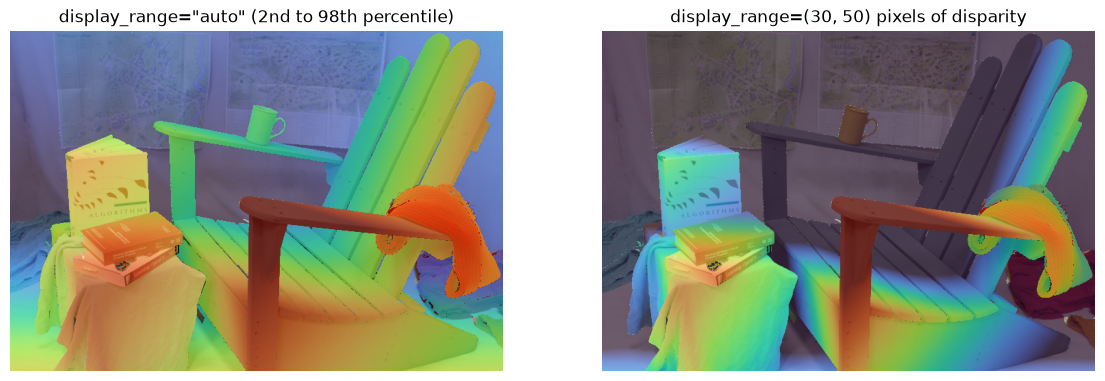

In [6]:
auto_range = sv.DepthAnnotator(opacity=0.6).annotate(left.copy(), truth)
fixed_range = sv.DepthAnnotator(display_range=(30, 50), opacity=0.6).annotate(
    left.copy(), truth
)
sv.plot_images_grid(
    [auto_range, fixed_range],
    grid_size=(1, 2),
    titles=[
        'display_range="auto" (2nd to 98th percentile)',
        "display_range=(30, 50) pixels of disparity",
    ],
    size=(14, 5),
)

## 2. Keep one colour scale across a video (PR #2692)

With `display_range="auto"` each frame is coloured with its own range, so when something near enters the frame, everything else shifts colour even though it has not moved. `sv.DepthClipRange.from_depth_maps` computes one range for the whole clip in a first pass; passed as `display_range`, it makes each colour mean the same distance on every frame.

First a clip where only one thing changes: the measured chair scene, with a near box sliding in from the left (made up for this demo, at 75 pixels of disparity). Top row: each frame's own range, so the chair turns cooler as the box takes over the warm colours. Bottom row: one range for the clip, so the chair keeps its colours.

DepthClipRange(display_range=(8.989021301269531, 75.0))


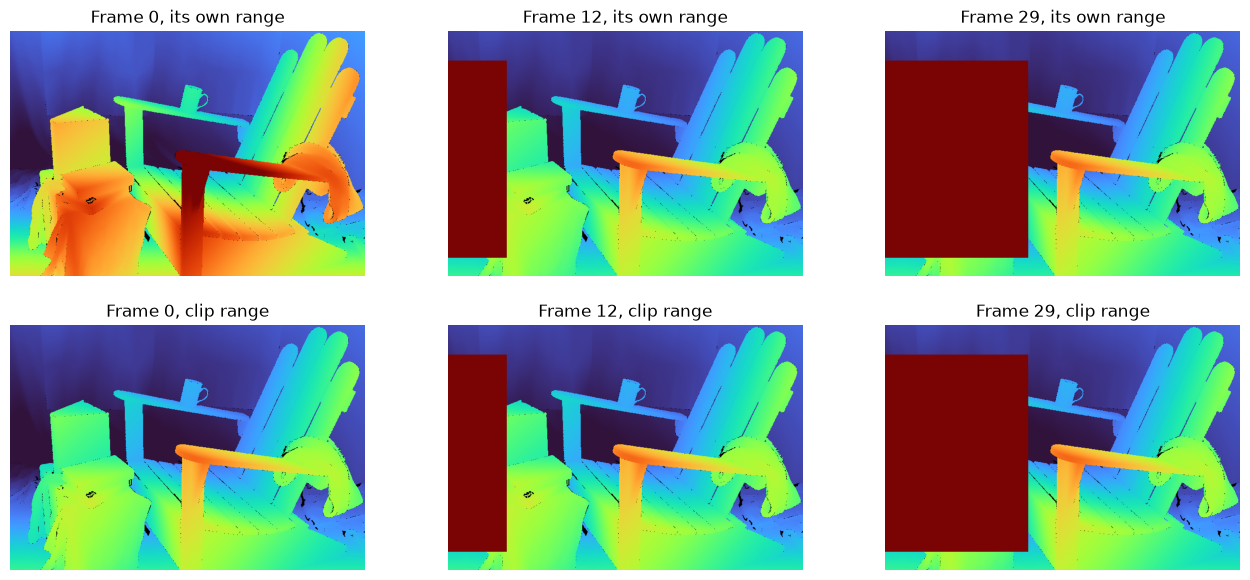

In [7]:
approach_maps = []
for step in range(30):
    values = truth.to_float()
    values[60:460, : 10 * step] = 75.0  # the box grows 10 pixels wider per frame
    approach_maps.append(sv.DepthMap(values, kind="disparity_px"))
approach_range = sv.DepthClipRange.from_depth_maps(approach_maps)
print(approach_range)

own_range_annotator = sv.DepthAnnotator()
clip_range_annotator = sv.DepthAnnotator(display_range=approach_range)
picked = [0, 12, 29]
sv.plot_images_grid(
    [
        own_range_annotator.annotate(np.zeros_like(left), approach_maps[i])
        for i in picked
    ]
    + [
        clip_range_annotator.annotate(np.zeros_like(left), approach_maps[i])
        for i in picked
    ],
    grid_size=(2, 3),
    titles=[f"Frame {i}, its own range" for i in picked]
    + [f"Frame {i}, clip range" for i in picked],
    size=(16, 7),
)

Now a real video: [YOLO26 depth](https://docs.ultralytics.com/) estimates metres for every frame of the first 3 seconds of a street video. The street itself does not move, but the model's estimate of it does: watch the printed median depth of the whole frame.

In [8]:
from ultralytics import YOLO

depth_model = YOLO("yolo26n-depth.pt")

CLIP_SECONDS = 3
FRAME_SIZE = (640, 360)
video_info = sv.VideoInfo.from_video_path(str(VIDEO_PATH))
frames = [
    sv.resize_image(frame, FRAME_SIZE)
    for frame in sv.get_video_frames_generator(
        str(VIDEO_PATH), end=int(video_info.fps * CLIP_SECONDS)
    )
]
depth_maps = [
    sv.DepthMap.from_ultralytics(depth_model(frame, verbose=False)[0])
    for frame in frames
]
clip_range = sv.DepthClipRange.from_depth_maps(depth_maps)

near_m, far_m = clip_range.display_range
medians = [
    np.median(depth_map.values[depth_map.valid_mask]) for depth_map in depth_maps
]
print(f"{len(frames)} frames, {depth_maps[0]}")
print(f"Clip range: {near_m:.1f} m to {far_m:.1f} m")
print(f"Median depth per frame: {min(medians):.1f} m to {max(medians):.1f} m")

75 frames, DepthMap(kind='depth_m', resolution_wh=(640, 360), camera=None)
Clip range: 3.3 m to 15.5 m
Median depth per frame: 5.6 m to 7.3 m


Both versions are written with `sv.VideoSink`. OpenCV writes MPEG-4 video that browsers do not play, so `ffmpeg` re-encodes a copy for display.

What to expect: the per-frame video re-stretches the colours on every frame, which hides the model's frame-to-frame wobble, so it looks calm. The clip-range video shows what the model actually says, so the whole street pulses a little warmer and cooler with it. A fixed range gives steady colours when the depth itself is steady, as in the chair clip above; with a single-camera model it makes the model's own wobble visible.

In [9]:
def to_browser_mp4(path: str) -> str:
    # Re-encode to H.264, the codec browsers play inline.
    web_path = path.replace(".mp4", "_h264.mp4")
    !ffmpeg -y -v error -i {path} -c:v libx264 -pix_fmt yuv420p -crf 30 {web_path}
    return web_path


per_frame_annotator = sv.DepthAnnotator(opacity=0.6)
steady_annotator = sv.DepthAnnotator(display_range=clip_range, opacity=0.6)
output_info = sv.VideoInfo(
    width=FRAME_SIZE[0], height=FRAME_SIZE[1], fps=video_info.fps
)

with (
    sv.VideoSink("per_frame_range.mp4", output_info) as per_frame_sink,
    sv.VideoSink("clip_range.mp4", output_info) as steady_sink,
):
    for frame, depth_map in zip(frames, depth_maps):
        per_frame_sink.write_frame(
            per_frame_annotator.annotate(frame.copy(), depth_map)
        )
        steady_sink.write_frame(steady_annotator.annotate(frame.copy(), depth_map))

display(Markdown('**Per-frame range** (`display_range="auto"`)'))
display(Video(to_browser_mp4("per_frame_range.mp4"), embed=True, width=480))
display(Markdown("**One range for the clip** (`display_range=clip_range`)"))
display(Video(to_browser_mp4("clip_range.mp4"), embed=True, width=480))

**Per-frame range** (`display_range="auto"`)

**One range for the clip** (`display_range=clip_range`)

## 3. Measure distances in metres (PR #2693)

Disparity becomes metres once you know the camera: depth = focal length x baseline / (disparity + doffs). The **baseline** is the distance between the two lenses, and **doffs** is a fixed pixel offset between the two views that Middlebury records. `sv.DepthCamera` holds these three numbers, read here from the dataset's `calib.txt`, and `to_depth()` converts. `resize` keeps the metres right: shrinking the map scales the disparity and the camera's pixel numbers together.

In [10]:
calib = dict(
    line.split("=", 1) for line in (DATA / "calib.txt").read_text().splitlines()
)
fx_px = float(calib["cam0"].strip("[]").split()[0])
camera = sv.DepthCamera(
    fx_px=fx_px,
    baseline_m=float(calib["baseline"]) / 1000,  # calib.txt gives millimetres
    doffs_px=float(calib["doffs"]),
)
truth_full = sv.DepthMap(truth_full.values, kind="disparity_px", camera=camera)
truth = truth_full.resize(SIZE)
print("Full size:", truth_full.camera)
print("Resized:  ", truth.camera)

depth = truth.to_depth()
print(depth)
x, y = 330, 300  # a point on the chair seat, in the 720 x 497 image
print(f"value_at({x}, {y}) on the resized map: {depth.value_at(x, y):.3f} m")
full_depth = truth_full.to_depth()
print(
    "Same point on the full-size map:      "
    f"{full_depth.value_at(x, y, resolution_wh=SIZE):.3f} m"
)

Full size: DepthCamera(fx_px=4161.221, baseline_m=0.17625200000000002, doffs_px=209.059)
Resized:   DepthCamera(fx_px=1040.30525, baseline_m=0.17625200000000002, doffs_px=52.26475)
DepthMap(kind='depth_m', resolution_wh=(720, 497), camera=DepthCamera(fx_px=1040.30525, baseline_m=0.17625200000000002, doffs_px=52.26475))
value_at(330, 300) on the resized map: 2.366 m
Same point on the full-size map:      2.368 m


`quantity="depth"` colours metres instead of disparity, spreading the colours evenly over distance where disparity gives most of them to near objects. It needs metres, so on a disparity map it works only with a camera. This scene spans only about 2 to 4 m, so the two look alike; the difference grows with deeper scenes. `crop` cuts out part of a map, for example to read the median distance of one region.

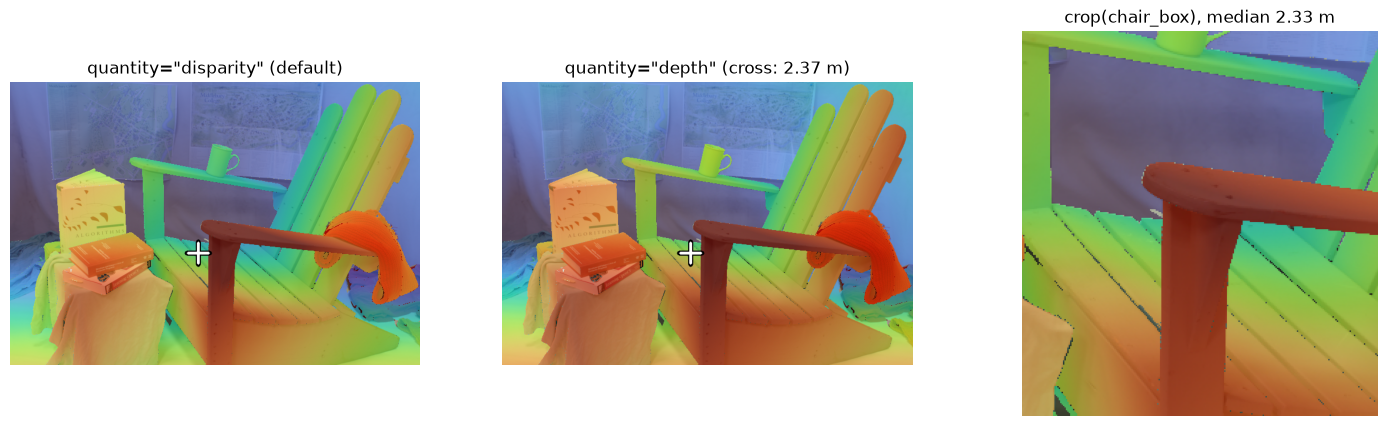

In [11]:
by_disparity = sv.DepthAnnotator(opacity=0.6).annotate(left.copy(), truth)
by_depth = sv.DepthAnnotator(quantity="depth", opacity=0.6).annotate(left.copy(), truth)
for image in (by_disparity, by_depth):
    cv2.drawMarker(image, (x, y), (0, 0, 0), cv2.MARKER_CROSS, 40, 7)
    cv2.drawMarker(image, (x, y), (255, 255, 255), cv2.MARKER_CROSS, 36, 3)

chair_box = (250, 150, 500, 420)
chair = depth.crop(chair_box)
chair_image = sv.crop_image(left, chair_box)
chair_image = sv.DepthAnnotator(quantity="depth", opacity=0.6).annotate(
    chair_image, chair
)
chair_median = np.nanmedian(chair.to_float())
sv.plot_images_grid(
    [by_disparity, by_depth, chair_image],
    grid_size=(1, 3),
    titles=[
        'quantity="disparity" (default)',
        f'quantity="depth" (cross: {depth.value_at(x, y):.2f} m)',
        f"crop(chair_box), median {chair_median:.2f} m",
    ],
    size=(18, 5),
)

Objects get distances the same way. Below, YOLO26 detects objects in a frame of the street video, YOLO26 depth estimates metres for the same frame, and `measure_detections` stores the median depth inside each box in `detections.data["depth_m"]`, ready for `sv.LabelAnnotator`. (The Middlebury scene has a single chair, so the street video makes a busier example.) These metres come from one camera and a small model, so read them as rough estimates.

16 objects; nearest 3.5 m


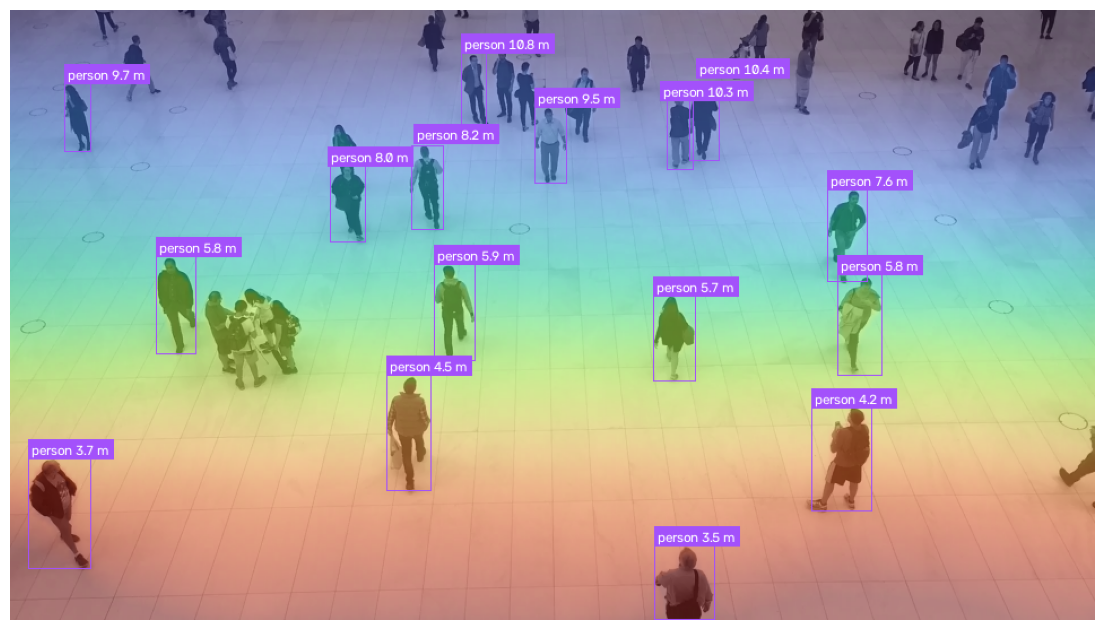

In [12]:
detector = YOLO("yolo26n.pt")
frame = sv.resize_image(
    next(sv.get_video_frames_generator(str(VIDEO_PATH))), (960, 540)
)

detections = sv.Detections.from_ultralytics(detector(frame, verbose=False)[0])
detections = detections[detections.confidence > 0.4]
frame_depth = sv.DepthMap.from_ultralytics(depth_model(frame, verbose=False)[0])
detections = frame_depth.measure_detections(detections)

labels = [
    f"{name} {distance:.1f} m"
    for name, distance in zip(detections.data["class_name"], detections.data["depth_m"])
]
annotated = sv.DepthAnnotator(opacity=0.45).annotate(frame.copy(), frame_depth)
annotated = sv.BoxAnnotator(thickness=1).annotate(annotated, detections)
annotated = sv.LabelAnnotator(
    text_scale=0.4, text_padding=3, smart_position=True
).annotate(annotated, detections, labels)
print(
    f"{len(detections)} objects; nearest {np.nanmin(detections.data['depth_m']):.1f} m"
)
sv.plot_image(annotated, size=(14, 8))

## 4. Load depth from models and dataset files (PR #2694)

Each loader turns one source's output into a `sv.DepthMap` that knows what its values measure (its **kind**: `disparity_px`, `depth_m` or `relative_inverse`), so everything above works the same whatever produced the depth.

**Ultralytics.** `from_ultralytics`, used in sections 2 and 3, reads YOLO26 depth results as metres (`depth_m`). On the chair photo, a single-camera guess can be far from the stereo measurement:

In [13]:
yolo_map = sv.DepthMap.from_ultralytics(depth_model(left, verbose=False)[0])
print(yolo_map)
print(
    f"YOLO26 at the cross: {yolo_map.value_at(x, y):.2f} m "
    f"(measured: {depth.value_at(x, y):.2f} m)"
)

DepthMap(kind='depth_m', resolution_wh=(720, 497), camera=None)
YOLO26 at the cross: 1.31 m (measured: 2.37 m)


**Hugging Face Transformers.** `from_transformers` reads the `depth-estimation` pipeline. The pipeline does not say what its model predicts, so you name the kind: Depth Anything predicts **relative** depth, larger is nearer but with no unit, which colours fine but cannot give metres.

DepthMap(kind='relative_inverse', resolution_wh=(720, 497), camera=None)


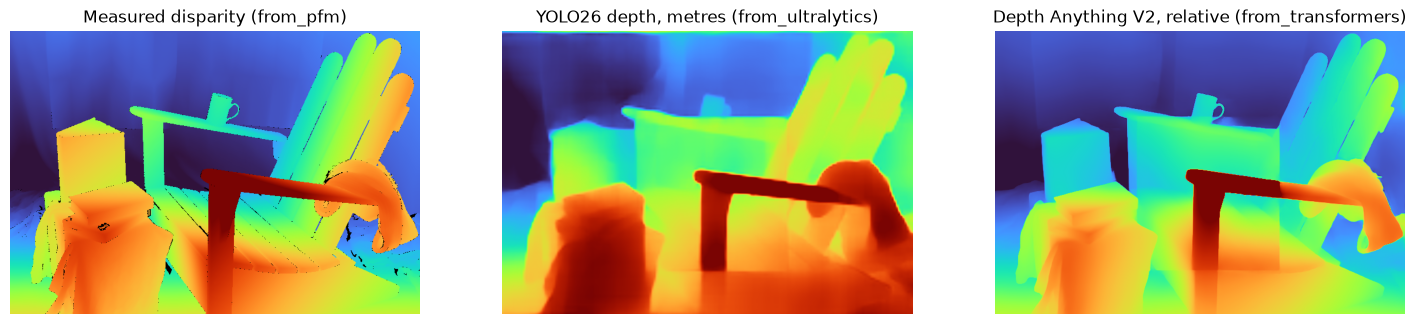

In [14]:
import torch
from transformers import pipeline

estimator = pipeline(
    "depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=0 if torch.cuda.is_available() else -1,
)
result = estimator(sv.cv2_to_pillow(left))
depth_anything_map = sv.DepthMap.from_transformers(result, kind="relative_inverse")
print(depth_anything_map)

sv.plot_images_grid(
    [
        sv.DepthAnnotator().annotate(np.zeros_like(left), truth),
        sv.DepthAnnotator().annotate(np.zeros_like(left), yolo_map),
        sv.DepthAnnotator().annotate(np.zeros_like(left), depth_anything_map),
    ],
    grid_size=(1, 3),
    titles=[
        "Measured disparity (from_pfm)",
        "YOLO26 depth, metres (from_ultralytics)",
        "Depth Anything V2, relative (from_transformers)",
    ],
    size=(18, 5),
)

**PFM files.** `from_pfm` reads the float format of Middlebury, ETH3D and SceneFlow, flipping its bottom-up rows and treating the infinities that mark unknown pixels as no depth.

In [15]:
pfm_map = sv.DepthMap.from_pfm(DATA / "disp0.pfm")
print(pfm_map)
values = pfm_map.to_float()
print(f"{(~pfm_map.valid_mask).mean():.2%} of pixels are unknown (inf in the file)")
print(f"Disparity from {np.nanmin(values):.1f} to {np.nanmax(values):.1f} pixels")

DepthMap(kind='disparity_px', resolution_wh=(2880, 1988), camera=None)
0.60% of pixels are unknown (inf in the file)
Disparity from 30.0 to 242.6 pixels


**16-bit PNG files.** KITTI and similar datasets store disparity as whole numbers in a 16-bit PNG: the value times 256, with 0 for no depth. To try `from_png16`, this cell writes the measured disparity that way with Pillow, loads it back, and checks it matches to within 1/256 of a pixel with the same holes.

In [16]:
codes = np.round(truth.to_float(no_depth_value=0.0) * 256).astype(np.uint16)
Image.fromarray(codes).save(DATA / "disparity_x256.png")

png_map = sv.DepthMap.from_png16(
    DATA / "disparity_x256.png", scale=256, kind="disparity_px"
)
max_error = np.nanmax(np.abs(png_map.to_float() - truth.to_float()))
print(png_map)
print(f"Same holes: {np.array_equal(png_map.valid_mask, truth.valid_mask)}")
print(f"Largest difference: {max_error:.5f} px")
print(f"Within 1/256 px: {max_error <= 1 / 256}")

DepthMap(kind='disparity_px', resolution_wh=(720, 497), camera=None)
Same holes: True
Largest difference: 0.00195 px
Within 1/256 px: True


**Roboflow Inference (optional).** `from_inference` reads the result of a Roboflow depth model. This cell calls Depth Anything V3 on Roboflow's hosted API, so it runs only with an API key: in Colab add a secret named `ROBOFLOW_API_KEY` (key icon in the left sidebar), or set the environment variable. Without one it prints how to enable it and moves on.

In [17]:
def roboflow_api_key() -> str | None:
    # Read the key from the environment, else from the Colab secret.
    if api_key := os.environ.get("ROBOFLOW_API_KEY"):
        return api_key
    try:
        from google.colab import userdata

        return userdata.get("ROBOFLOW_API_KEY")
    except Exception:
        return None


api_key = roboflow_api_key()

if not api_key:
    print(
        "Skipped: no Roboflow API key. Get one at "
        "https://app.roboflow.com/settings/api, add it as the Colab secret "
        "ROBOFLOW_API_KEY (or the environment variable), and run this cell again."
    )
else:
    try:
        from inference_sdk import InferenceHTTPClient
    except ImportError:
        %pip install -q inference-sdk
        from inference_sdk import InferenceHTTPClient

    client = InferenceHTTPClient(
        api_url="https://serverless.roboflow.com", api_key=api_key
    )
    inference_result = client.depth_estimation(
        left, model_id="depth-anything-v3/small", depth_map_format="png16"
    )
    inference_map = sv.DepthMap.from_inference(inference_result)
    print(inference_map)
    sv.plot_images_grid(
        [
            sv.DepthAnnotator(opacity=0.6).annotate(left.copy(), inference_map),
            sv.DepthAnnotator().annotate(np.zeros_like(left), inference_map),
        ],
        grid_size=(1, 2),
        titles=[
            "Depth Anything V3 via Roboflow (from_inference) over the photo",
            "The same map alone",
        ],
        size=(14, 5),
    )

Skipped: no Roboflow API key. Get one at https://app.roboflow.com/settings/api, add it as the Colab secret ROBOFLOW_API_KEY (or the environment variable), and run this cell again.


## What to look for

- [ ] Section 1: holes in the StereoSGBM map stay unpainted (photo or black shows through), and warm means near in every colour table.
- [ ] Section 1: a fixed `display_range` clamps values outside it to the end colours.
- [ ] Section 2: in the chair clip, the chair shifts colour with its own range (top row) and holds with the clip range (bottom row).
- [ ] Section 2: in the street video, the clip range shows the model's frame-to-frame wobble that the per-frame range hides.
- [ ] Section 3: the resized and full-size maps give the same metres at the cross, and the camera's pixel numbers shrink with the map.
- [ ] Section 3: labels read like `person 9.8 m`, nearer people with smaller numbers.
- [ ] Section 4: each loader prints the right kind (`depth_m` for YOLO26, `relative_inverse` for Depth Anything, `disparity_px` for the files), and the 16-bit PNG round trip stays within 1/256 px.

**Credits:** stereo scene "Adirondack" from the Middlebury 2014 dataset: D. Scharstein, H. Hirschmüller, Y. Kitajima, G. Krathwohl, N. Nesic, X. Wang and P. Westling, "High-resolution stereo datasets with subpixel-accurate ground truth", GCPR 2014. The people-walking video is from Roboflow.